In [1]:
from pathlib import Path
import sys
import json

PROJECT_ROOT = Path.cwd()

# If the notebook is launched from the notebooks/ folder,
# move one level up to the project root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FOODSEG_ROOT = PROJECT_ROOT / "data" / "raw" / "FoodSeg103"
PARQUET_DIR = FOODSEG_ROOT / "data"
LABEL_PATH = FOODSEG_ROOT / "id2label.json"

print("Python executable:")
print(sys.executable)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nFoodSeg103 root:")
print(FOODSEG_ROOT)

print("\nRequired paths:")
print("Parquet directory exists:", PARQUET_DIR.exists())
print("Label file exists:", LABEL_PATH.exists())

if PARQUET_DIR.exists():
    print("\nParquet files:")
    for path in sorted(PARQUET_DIR.glob("*.parquet")):
        print(f"  {path.name} — {path.stat().st_size:,} bytes")

if LABEL_PATH.exists():
    with open(LABEL_PATH, "r", encoding="utf-8") as f:
        labels = json.load(f)

    print("\nLabel count:", len(labels))
    print("Background:", labels.get("0"))
    print("Food classes:", len(labels) - 1)

Python executable:
c:\Users\SANDEEP\Documents\NutriVision\.venv\Scripts\python.exe

Project root:
c:\Users\SANDEEP\Documents\NutriVision

FoodSeg103 root:
c:\Users\SANDEEP\Documents\NutriVision\data\raw\FoodSeg103

Required paths:
Parquet directory exists: True
Label file exists: True

Parquet files:
  train-00000-of-00003.parquet — 351,240,914 bytes
  train-00001-of-00003.parquet — 356,813,558 bytes
  train-00002-of-00003.parquet — 431,463,278 bytes
  validation-00000-of-00001.parquet — 115,186,173 bytes

Label count: 104
Background: background
Food classes: 103


In [2]:
import pandas as pd

train_path = PARQUET_DIR / "train-00000-of-00003.parquet"

df_sample = pd.read_parquet(train_path)

print("DataFrame shape:", df_sample.shape)
print("\nColumns:")
print(df_sample.columns.tolist())

print("\nDtypes:")
print(df_sample.dtypes)

print("\nFirst record structure:")
for column in df_sample.columns:
    value = df_sample.iloc[0][column]
    print(f"\n--- {column} ---")
    print("Type:", type(value))
    
    if hasattr(value, "keys"):
        print("Keys:", list(value.keys()))
    elif hasattr(value, "shape"):
        print("Shape:", value.shape)
        print("Dtype:", getattr(value, "dtype", None))
    else:
        print("Value:", value)

DataFrame shape: (1661, 4)

Columns:
['image', 'label', 'classes_on_image', 'id']

Dtypes:
image               object
label               object
classes_on_image    object
id                   int64
dtype: object

First record structure:

--- image ---
Type: <class 'dict'>
Keys: ['bytes', 'path']

--- label ---
Type: <class 'dict'>
Keys: ['bytes', 'path']

--- classes_on_image ---
Type: <class 'numpy.ndarray'>
Shape: (4,)
Dtype: int64

--- id ---
Type: <class 'numpy.int64'>
Shape: ()
Dtype: int64


In [3]:
from io import BytesIO
from PIL import Image
import numpy as np

record = df_sample.iloc[0]

image_bytes = record["image"]["bytes"]
mask_bytes = record["label"]["bytes"]

image = Image.open(BytesIO(image_bytes))
mask = Image.open(BytesIO(mask_bytes))

image_array = np.asarray(image)
mask_array = np.asarray(mask)

print("IMAGE")
print("Format:", image.format)
print("Mode:", image.mode)
print("Size:", image.size)
print("Array shape:", image_array.shape)
print("Array dtype:", image_array.dtype)

print("\nMASK")
print("Format:", mask.format)
print("Mode:", mask.mode)
print("Size:", mask.size)
print("Array shape:", mask_array.shape)
print("Array dtype:", mask_array.dtype)

unique_values = np.unique(mask_array)

print("\nMASK VALUES")
print("Number of unique values:", len(unique_values))
print("Unique values:", unique_values)

print("\nCLASSES_ON_IMAGE")
print("Values:", record["classes_on_image"])
print("Number of classes:", len(record["classes_on_image"]))

print("\nID")
print("Value:", record["id"])

IMAGE
Format: JPEG
Mode: RGB
Size: (512, 384)
Array shape: (384, 512, 3)
Array dtype: uint8

MASK
Format: PNG
Mode: L
Size: (512, 384)
Array shape: (384, 512)
Array dtype: uint8

MASK VALUES
Number of unique values: 4
Unique values: [ 0 48 66 90]

CLASSES_ON_IMAGE
Values: [ 0 48 66 90]
Number of classes: 4

ID
Value: 0


In [6]:
from io import BytesIO
from PIL import Image
import numpy as np

parquet_files = sorted(PARQUET_DIR.glob("*.parquet"))

EXPECTED_CLASS_VALUES = set(range(104))

total_records = 0
invalid_dimensions = []
invalid_mask_values = []
class_mismatches = []

for parquet_path in parquet_files:
    print(f"\nChecking: {parquet_path.name}")

    df = pd.read_parquet(parquet_path)

    file_count = len(df)
    total_records += file_count

    for row_index, record in df.iterrows():

        try:
            image = Image.open(BytesIO(record["image"]["bytes"]))
            mask = Image.open(BytesIO(record["label"]["bytes"]))

            image_size = image.size
            mask_size = mask.size

            if image_size != mask_size:
                invalid_dimensions.append(
                    (parquet_path.name, row_index, image_size, mask_size)
                )

            mask_array = np.asarray(mask)

            unique_values = set(np.unique(mask_array).tolist())

            if not unique_values.issubset(EXPECTED_CLASS_VALUES):
                invalid_mask_values.append(
                    (
                        parquet_path.name,
                        row_index,
                        sorted(unique_values),
                    )
                )

            mask_classes = set(unique_values)

            listed_classes = set(
                np.asarray(record["classes_on_image"]).tolist()
            )

            if mask_classes != listed_classes:
                class_mismatches.append(
                    (
                        parquet_path.name,
                        row_index,
                        sorted(mask_classes),
                        sorted(listed_classes),
                    )
                )

        except Exception as exc:
            invalid_dimensions.append(
                (parquet_path.name, row_index, "ERROR", str(exc))
            )

    print(f"Records checked: {file_count}")

print("\n" + "=" * 60)
print("DATA VALIDATION SUMMARY")
print("=" * 60)

print("Total records checked:", total_records)

print("Invalid image/mask dimensions:", len(invalid_dimensions))
print("Invalid mask class values:", len(invalid_mask_values))
print("classes_on_image mismatches:", len(class_mismatches))

if invalid_dimensions:
    print("\nFirst dimension problems:")
    for item in invalid_dimensions[:10]:
        print(item)

if invalid_mask_values:
    print("\nFirst invalid mask-value problems:")
    for item in invalid_mask_values[:10]:
        print(item)

if class_mismatches:
    print("\nFirst classes_on_image mismatches:")
    for item in class_mismatches[:10]:
        print(item)


Checking: train-00000-of-00003.parquet
Records checked: 1661

Checking: train-00001-of-00003.parquet
Records checked: 1661

Checking: train-00002-of-00003.parquet
Records checked: 1661

Checking: validation-00000-of-00001.parquet
Records checked: 2135

DATA VALIDATION SUMMARY
Total records checked: 7118
Invalid image/mask dimensions: 4
Invalid mask class values: 0
classes_on_image mismatches: 0

First dimension problems:
('train-00000-of-00003.parquet', 271, (384, 512), (512, 384))
('train-00001-of-00003.parquet', 920, (384, 512), (512, 384))
('train-00002-of-00003.parquet', 643, (384, 512), (512, 384))
('train-00002-of-00003.parquet', 1299, (333, 500), (500, 333))


In [5]:
problem_records = [
    ("train-00000-of-00003.parquet", 271),
    ("train-00001-of-00003.parquet", 920),
    ("train-00002-of-00003.parquet", 643),
    ("train-00002-of-00003.parquet", 1299),
]

for parquet_name, row_index in problem_records:

    parquet_path = PARQUET_DIR / parquet_name
    df_problem = pd.read_parquet(parquet_path)

    record = df_problem.iloc[row_index]

    image = Image.open(BytesIO(record["image"]["bytes"]))
    mask = Image.open(BytesIO(record["label"]["bytes"]))

    mask_array = np.asarray(mask)

    print("\n" + "=" * 70)
    print(f"FILE : {parquet_name}")
    print(f"ROW  : {row_index}")
    print("=" * 70)

    print("Image size :", image.size)
    print("Mask size  :", mask.size)

    print("Image mode :", image.mode)
    print("Mask mode  :", mask.mode)

    print("Image array shape :", np.asarray(image).shape)
    print("Mask array shape  :", mask_array.shape)

    print("Mask values :", np.unique(mask_array))
    print("classes_on_image :", record["classes_on_image"])

    print("Record ID :", record["id"])
    


FILE : train-00000-of-00003.parquet
ROW  : 271
Image size : (384, 512)
Mask size  : (512, 384)
Image mode : RGB
Mask mode  : L
Image array shape : (512, 384, 3)
Mask array shape  : (384, 512)
Mask values : [ 0 14 32]
classes_on_image : [ 0 14 32]
Record ID : 271

FILE : train-00001-of-00003.parquet
ROW  : 920
Image size : (384, 512)
Mask size  : (512, 384)
Image mode : RGB
Mask mode  : L
Image array shape : (512, 384, 3)
Mask array shape  : (384, 512)
Mask values : [ 0  8 54 59 70]
classes_on_image : [ 0  8 54 59 70]
Record ID : 2581

FILE : train-00002-of-00003.parquet
ROW  : 643
Image size : (384, 512)
Mask size  : (512, 384)
Image mode : RGB
Mask mode  : L
Image array shape : (512, 384, 3)
Mask array shape  : (384, 512)
Mask values : [ 0 18 47 64]
classes_on_image : [ 0 18 47 64]
Record ID : 3965

FILE : train-00002-of-00003.parquet
ROW  : 1299
Image size : (333, 500)
Mask size  : (500, 333)
Image mode : RGB
Mask mode  : L
Image array shape : (500, 333, 3)
Mask array shape  : (333,

In [7]:
for parquet_name, row_index in problem_records:

    parquet_path = PARQUET_DIR / parquet_name
    df_problem = pd.read_parquet(parquet_path)
    record = df_problem.iloc[row_index]

    image = Image.open(BytesIO(record["image"]["bytes"]))
    mask = Image.open(BytesIO(record["label"]["bytes"]))

    print(
        f"{parquet_name} | "
        f"row={row_index} | "
        f"id={record['id']} | "
        f"image={image.size} | "
        f"mask={mask.size} | "
        f"classes={record['classes_on_image'].tolist()}"
    )

train-00000-of-00003.parquet | row=271 | id=271 | image=(384, 512) | mask=(512, 384) | classes=[0, 14, 32]
train-00001-of-00003.parquet | row=920 | id=2581 | image=(384, 512) | mask=(512, 384) | classes=[0, 8, 54, 59, 70]
train-00002-of-00003.parquet | row=643 | id=3965 | image=(384, 512) | mask=(512, 384) | classes=[0, 18, 47, 64]
train-00002-of-00003.parquet | row=1299 | id=4621 | image=(333, 500) | mask=(500, 333) | classes=[0, 58, 81]


In [10]:
from scipy import ndimage

# Use the first sample we already inspected
record = df_sample.iloc[0]

image = Image.open(BytesIO(record["image"]["bytes"]))
mask = Image.open(BytesIO(record["label"]["bytes"]))

image_array = np.asarray(image)
mask_array = np.asarray(mask)

print("Image shape:", image_array.shape)
print("Mask shape:", mask_array.shape)
print("Classes:", record["classes_on_image"])

boxes = []

food_class_ids = [
    int(class_id)
    for class_id in np.unique(mask_array)
    if class_id != 0
]

for class_id in food_class_ids:

    class_mask = mask_array == class_id

    # Find connected regions for this food class
    labeled_mask, num_components = ndimage.label(class_mask)

    for component_id in range(1, num_components + 1):

        ys, xs = np.where(labeled_mask == component_id)

        if len(xs) == 0:
            continue

        x_min = int(xs.min())
        y_min = int(ys.min())
        x_max = int(xs.max())
        y_max = int(ys.max())

        boxes.append(
            {
                "class_id": class_id,
                "component_id": component_id,
                "x_min": x_min,
                "y_min": y_min,
                "x_max": x_max,
                "y_max": y_max,
                "area": len(xs),
            }
        )

print("\nCONNECTED COMPONENT BOXES")
print("=" * 60)

for box in boxes:
    print(box)

print("\nTotal boxes:", len(boxes))

Image shape: (384, 512, 3)
Mask shape: (384, 512)
Classes: [ 0 48 66 90]

CONNECTED COMPONENT BOXES
{'class_id': 48, 'component_id': 1, 'x_min': 0, 'y_min': 125, 'x_max': 261, 'y_max': 383, 'area': 47014}
{'class_id': 66, 'component_id': 1, 'x_min': 154, 'y_min': 40, 'x_max': 511, 'y_max': 344, 'area': 73227}
{'class_id': 90, 'component_id': 1, 'x_min': 0, 'y_min': 0, 'x_max': 204, 'y_max': 234, 'area': 29097}

Total boxes: 3


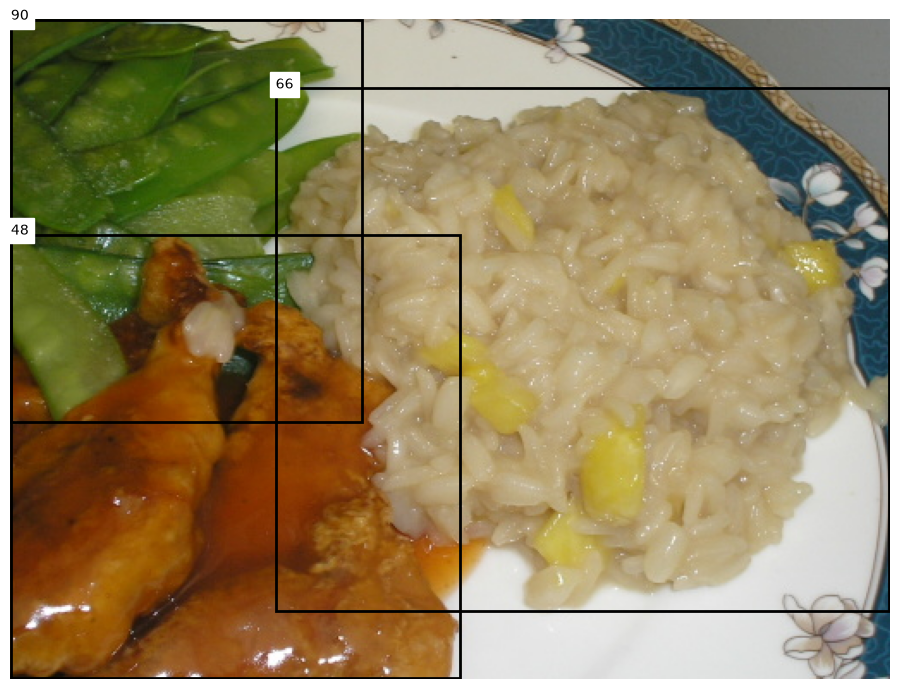

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(10, 7))

ax.imshow(image_array)

for box in boxes:
    x_min = box["x_min"]
    y_min = box["y_min"]
    width = box["x_max"] - x_min
    height = box["y_max"] - y_min

    rect = Rectangle(
        (x_min, y_min),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rect)

    ax.text(
        x_min,
        y_min,
        str(box["class_id"]),
        fontsize=10,
        backgroundcolor="white"
    )

ax.axis("off")
plt.tight_layout()
plt.show()

In [13]:
from pathlib import Path
import sys
import tensorflow as tf

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name != "NutriVision":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.segmentation.data import load_parquet_dataset

test_parquet = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "FoodSeg103"
    / "data"
    / "train-00000-of-00003.parquet"
)

dataset = load_parquet_dataset(test_parquet)

image_tensor, mask_tensor = next(iter(dataset))

print("IMAGE")
print("Shape:", image_tensor.shape)
print("Dtype:", image_tensor.dtype)
print("Min:", tf.reduce_min(image_tensor).numpy())
print("Max:", tf.reduce_max(image_tensor).numpy())

print("\nMASK")
print("Shape:", mask_tensor.shape)
print("Dtype:", mask_tensor.dtype)

mask_values = tf.unique(
    tf.reshape(mask_tensor, [-1])
).y.numpy()

print("Unique mask values:", np.sort(mask_values))

IMAGE
Shape: (512, 512, 3)
Dtype: <dtype: 'float32'>
Min: 0.0
Max: 255.0

MASK
Shape: (512, 512)
Dtype: <dtype: 'int32'>
Unique mask values: [ 0 48 66 90]
